# Analyse du Data Drift

Ce notebook analyse le **data drift** entre :

- les données de référence utilisées pour l'entraînement du modèle
- les données issues de l'utilisation de l'application en production

Les données de production sont enregistrées dans les logs de prédictions générés par l'application Streamlit.

L'objectif est d'identifier d'éventuelles dérives dans la distribution des variables utilisées par le modèle de scoring.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Chargement des données

In [2]:
reference_df = pd.read_csv("../data/reference/clients_demo.csv")

logs_df = pd.read_json("../logs/predictions.jsonl", lines=True)

print("Reference shape:", reference_df.shape)
print("Production shape:", logs_df.shape)

Reference shape: (21, 28)
Production shape: (25, 12)


## Aperçu des données

In [3]:
reference_df.head()

,client_id,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,...,heure_supplementaires,augementation_salaire_precedente,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,C001,29,0,6100,Célibataire,31,Analyste,0,8,4,...,1,7.1,0,2,45,3,RH,Rare,1,0
1,C002,31,0,4000,Divorcé(e),33,Analyste,7,7,5,...,0,7.9,2,1,15,0,Commerce,Rare,3,0
2,C003,51,1,6200,Célibataire,69,Technicien,2,25,5,...,0,9.7,3,4,5,1,Marketing,Fréquent,1,1
3,C004,42,0,3400,Marié(e),13,Chef de projet,6,18,15,...,0,1.8,1,6,39,0,Commerce,Rare,7,5
4,C005,51,1,5900,Divorcé(e),92,Chef de projet,6,22,8,...,0,1.8,1,8,34,0,Marketing,Rare,1,0


In [4]:
logs_df.head()

,ts,mode,threshold,p_default,decision,latency_ms,n_features,age,revenu_mensuel,distance_domicile_travail,annee_experience_totale,session_id
0,2026-03-12T08:20:20.166394+00:00,single,0.5,2.586394e-18,ACCORD,3.646,27,29,6100,45,8,NaN
1,2026-03-15T00:02:29.661615+00:00,single,0.5,9.900422e-01,REFUS,12.595,27,18,1000,25,0,NaN
2,2026-03-15T00:05:43.401030+00:00,single,0.5,8.158503e-02,ACCORD,3.392,27,21,1200,30,1,NaN
3,2026-03-15T00:07:13.286043+00:00,single,0.5,6.224826e-02,ACCORD,4.371,27,24,1400,28,2,NaN
4,2026-03-15T00:07:54.863993+00:00,single,0.5,6.224826e-02,ACCORD,4.045,27,24,1400,28,2,NaN


Les données de production correspondent aux prédictions réalisées par l'application.
Chaque ligne représente une prédiction avec certaines variables du client.

## Sélection des variables à analyser

Les variables suivantes sont analysées car elles sont importantes dans le modèle et interprétables métier.

In [5]:
variables = [
    "revenu_mensuel",
    "distance_domicile_travail",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "nb_formations_suivies"
]

## Comparaison visuelle des distributions

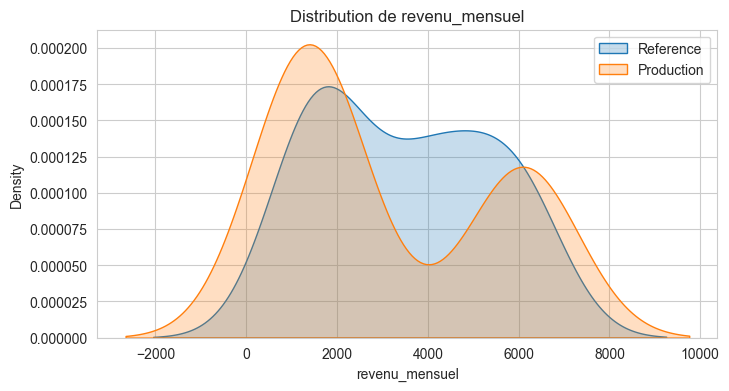

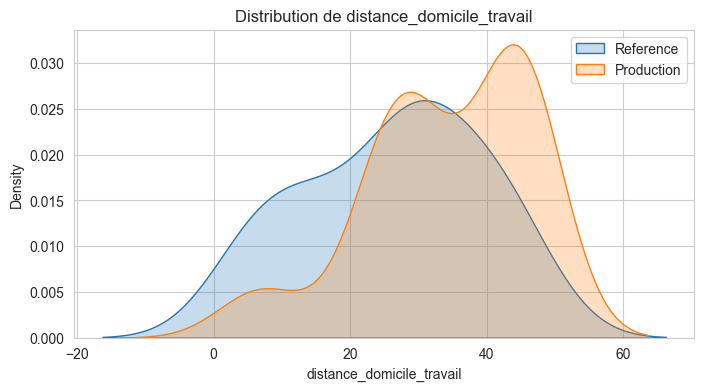

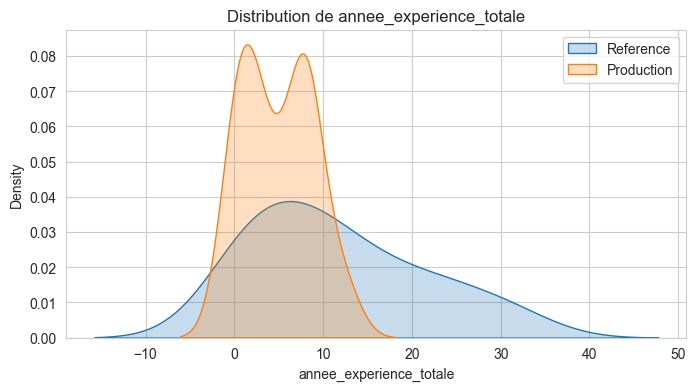

In [6]:
for var in variables:
    
    if var not in logs_df.columns:
        continue

    plt.figure(figsize=(8,4))

    sns.kdeplot(reference_df[var], label="Reference", fill=True)
    sns.kdeplot(logs_df[var], label="Production", fill=True)

    plt.title(f"Distribution de {var}")
    plt.legend()

    plt.show()

## Fonction PSI (Population Stability Index)

In [7]:
def compute_psi(expected, actual, bins=10):

    breakpoints = np.linspace(0, 100, bins + 1)
    
    expected_perc = np.percentile(expected, breakpoints)
    
    expected_counts = np.histogram(expected, bins=expected_perc)[0]
    actual_counts = np.histogram(actual, bins=expected_perc)[0]

    expected_ratio = expected_counts / len(expected)
    actual_ratio = actual_counts / len(actual)

    # éviter division par zéro
    expected_ratio = np.where(expected_ratio == 0, 0.0001, expected_ratio)
    actual_ratio = np.where(actual_ratio == 0, 0.0001, actual_ratio)

    psi = np.sum((actual_ratio - expected_ratio) * np.log(actual_ratio / expected_ratio))

    return psi

## Calcul du drift

In [8]:
psi_results = {}

for var in variables:
    
    if var not in logs_df.columns:
        continue
    
    psi = compute_psi(reference_df[var], logs_df[var])
    
    psi_results[var] = psi

psi_results

{'revenu_mensuel': np.float64(3.72450421356301),
 'distance_domicile_travail': np.float64(2.044239625001075),
 'annee_experience_totale': np.float64(3.0591342083532567)}

## Interprétation

In [9]:
for var, psi in psi_results.items():
    
    if psi < 0.1:
        interpretation = "Stable"
    elif psi < 0.25:
        interpretation = "Drift modéré"
    else:
        interpretation = "Drift important"
        
    print(f"{var} : PSI = {psi:.3f} → {interpretation}")

revenu_mensuel : PSI = 3.725 → Drift important
distance_domicile_travail : PSI = 2.044 → Drift important
annee_experience_totale : PSI = 3.059 → Drift important


### Conclusion

L'analyse du data drift permet de détecter les changements dans la distribution des variables utilisées par le modèle.

Un PSI inférieur à 0.1 indique généralement une distribution stable.

Un PSI supérieur à 0.25 peut signaler un drift significatif nécessitant une réévaluation du modèle.
